<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-GomezGomez/Evaluacion2/gomezgomez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,085 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,600 kB]
Hit:1

In [ ]:
#Fase n°1, generacion de los datos y entrenamiento de las redes neuronales

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Cargar los datos
datos = np.load('datos_4098.npz')
X = datos['X']       # Señales: (45, 256)
y = datos['y']       # Regimen de datos: (45,)
t = datos['t']       # Vector de tiempo: (256,)

def predict(params, X_batch):
    W1, W2 = params
    # Aplicamos W1 a cada señal de la matriz X
    hidden = jnp.tanh(jnp.dot(X_batch, W1.T))
    X_hat = jnp.dot(hidden, W2.T)
    return X_hat

def mse_loss(params, X_batch):
    X_hat = predict(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

def init_fourier(t, key, K=30):
    # W1: Construimos la Base de Fourier manualmente en numpy
    W1 = np.zeros((2 * K, len(t)))
    for k in range(1, K + 1):
        W1[2 * (k - 1), :] = np.sin(2 * jnp.pi * k * t)
        W1[2 * (k - 1) + 1, :] = np.cos(2 * jnp.pi * k * t)

    # W2: Inicialización aleatoria con factor de escala pequeño
    key_w2, _ = jax.random.split(key)
    W2 = jax.random.normal(key_w2, (len(t), 2 * K)) * 0.1

    return [jnp.array(W1), W2]

def init_random(t, key, K=30):
    key_w1, key_w2 = jax.random.split(key)
    # W1 y W2 puramente aleatorias
    W1 = jax.random.normal(key_w1, (2 * K, len(t))) * 0.1
    W2 = jax.random.normal(key_w2, (len(t), 2 * K)) * 0.1
    return [W1, W2]

@jax.jit
def update(params, X_batch, lr=0.1):
    loss, grads = jax.value_and_grad(mse_loss)(params, X_batch)
    # Descenso de gradiente estándar
    new_params = [p - lr * g for p, g in zip(params, grads)]
    return new_params, loss

def train_network(params, X_train, epochs=2000, lr=0.1):
    loss_history = []
    for epoch in range(epochs):
        params, loss = update(params, X_train, lr)
        loss_history.append(loss)
    return params, loss_history

# Filtrar solo el régimen 0 (sin dispersión)
X_regimen_0 = X[y == 0]

# Inicializar semillas de JAX
key = jax.random.PRNGKey(4098)
key_fourier, key_random = jax.random.split(key)

# 1. Entrenar con inicialización de Fourier
params_fourier = init_fourier(t, key_fourier)
params_fourier_final, loss_fourier = train_network(params_fourier, X_regimen_0)

# 2. Entrenar con inicialización Aleatoria
params_random = init_random(t, key_random)
params_random_final, loss_random = train_network(params_random, X_regimen_0)


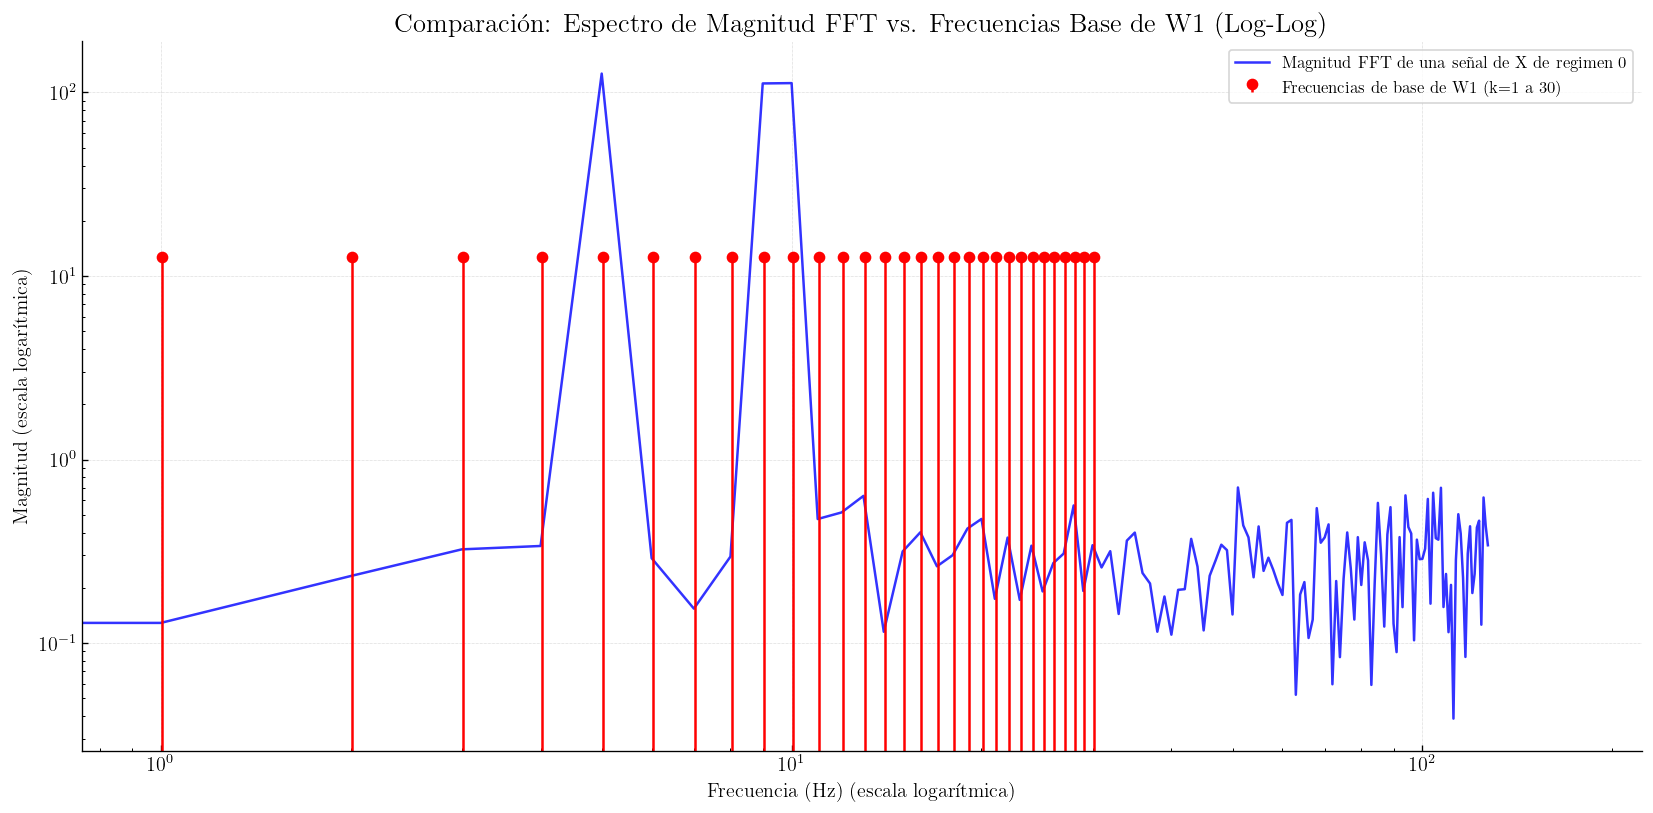

La señal media cuadrática del dataset (X**2).mean() es: 0.7120


In [20]:
#Fase n°2, comparacion de las señales por medio de fft, calculo de la señal media

import numpy as np
import matplotlib.pyplot as plt

# Seleccionar una señal de ejemplo del régimen 0 y calcular su FFT
sample_signal = X_regimen_0[0] # Tomamos la primera señal del régimen 0
fft_signal = np.fft.fft(sample_signal)

# Calcular las frecuencias correspondientes a la FFT
N = len(sample_signal) # Número de puntos en la señal
dt = t[1] - t[0]       # Intervalo de tiempo entre muestras (asumiendo t es equiespaciado)
frequencies = np.fft.fftfreq(N, d=dt)

# Solo considerar las frecuencias positivas y sus magnitudes correspondientes para el plot
positive_freq_indices = frequencies >= 0
positive_frequencies = frequencies[positive_freq_indices]
fft_magnitudes = np.abs(fft_signal[positive_freq_indices])

# Extraer las frecuencias utilizadas en la construcción de W1 de la inicialización Fourier
# K se define en init_fourier (en la celda anterior) como 30
K_fourier = 30
T_period = t[-1] - t[0] # Duración total del vector de tiempo
w1_basis_frequencies = np.array([k / T_period for k in range(1, K_fourier + 1)])

# Crear la gráfica de comparación
plt.figure(figsize=(14, 7))

# Graficar la magnitud de la FFT de la señal y marcar las frecuencias de W1
plt.loglog(positive_frequencies, fft_magnitudes, label='Magnitud FFT de una señal de X de regimen 0', color='blue', alpha=0.8)
plt.stem(w1_basis_frequencies, np.ones_like(w1_basis_frequencies) * np.max(fft_magnitudes) * 0.1,
         linefmt='red', markerfmt='ro', basefmt=' ', label=f'Frecuencias de base de W1 (k=1 a {K_fourier})')

plt.title('Comparación: Espectro de Magnitud FFT vs. Frecuencias Base de W1 (Log-Log)', fontsize=16)
plt.xlabel('Frecuencia (Hz) (escala logarítmica)', fontsize=12)
plt.ylabel('Magnitud (escala logarítmica)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0.75, None)
plt.tight_layout()
plt.show()

# Imprimir la señal media cuadrática del dataset
mean_squared_X = (X**2).mean()
print(f'La señal media cuadrática del dataset (X**2).mean() es: {mean_squared_X:.4f}')

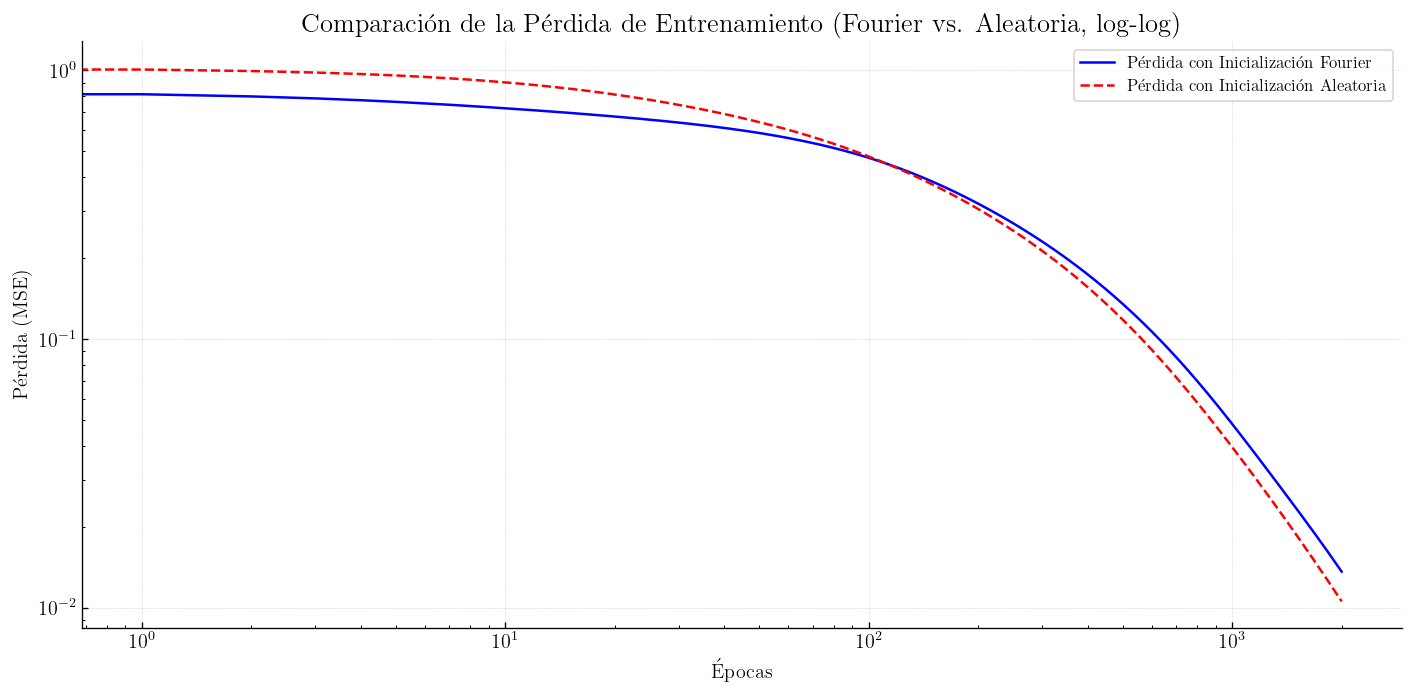

In [ ]:
#Fase n°3, comparacion de la perdida de entrenamiento de las redes neuronales

import matplotlib.pyplot as plt

# Asegurarse de que las listas de pérdida sean arrays de JAX o NumPy para un ploteo fácil
loss_fourier_np = jnp.array(loss_fourier)
loss_random_np = jnp.array(loss_random)

# Crear la figura y los ejes para la gráfica
plt.figure(figsize=(12, 6))

# Graficar la pérdida con inicialización de Fourier
plt.loglog(loss_fourier_np, label='Pérdida con Inicialización Fourier', color='blue')

# Graficar la pérdida con inicialización Aleatoria
plt.loglog(loss_random_np, label='Pérdida con Inicialización Aleatoria', color='red', linestyle='--')

# Añadir título y etiquetas a los ejes
plt.title('Comparación de la Pérdida de Entrenamiento (Fourier vs. Aleatoria, log-log)', fontsize=16)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)

# Añadir leyenda para identificar las líneas
plt.legend(fontsize=10)

# Añadir una cuadrícula para mejor legibilidad
plt.grid(True, linestyle=':', alpha=0.7)

# Ajustar el diseño para evitar recortes de etiquetas
plt.tight_layout()

# Mostrar la gráfica
plt.show()